In [5]:
#loading the datasets
from google.colab import files

uploaded = files.upload()

Saving adverse_events.csv to adverse_events.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving lab_results.csv to lab_results.csv
Saving medication_adherence.csv to medication_adherence.csv
Saving participants.csv to participants.csv
Saving products.csv to products.csv
Saving treatment_assignments.csv to treatment_assignments.csv
Saving trial_sites.csv to trial_sites.csv
Saving visits.csv to visits.csv


In [6]:
participants = pd.read_csv("participants.csv")
visits = pd.read_csv("visits.csv")
treatment_assignments = pd.read_csv("treatment_assignments.csv")
lab_results = pd.read_csv("lab_results.csv")
adverse_events = pd.read_csv("adverse_events.csv")
medication_adherence = pd.read_csv("medication_adherence.csv")
trial_sites = pd.read_csv("trial_sites.csv")
products = pd.read_csv("products.csv")

In [7]:
print("Participants:", participants.shape)
print("Visits:", visits.shape)
print("Treatment Assignments:", treatment_assignments.shape)
print("Lab Results:", lab_results.shape)
print("Adverse Events:", adverse_events.shape)
print("Medication Adherence:", medication_adherence.shape)
print("Trial Sites:", trial_sites.shape)
print("Products:", products.shape)

Participants: (10000, 11)
Visits: (40000, 3)
Treatment Assignments: (10000, 4)
Lab Results: (60000, 5)
Adverse Events: (3200, 6)
Medication Adherence: (5000, 5)
Trial Sites: (40, 4)
Products: (2, 3)


In [8]:
#missing value check
print("Participants:")
print(participants.head())

print("\nMissing values in participants:")
print(participants.isnull().sum())

Participants:
   Participant_ID  Site_ID  Age  Gender Baseline_Severity Risk_Category  \
0               1        5   61  Female          Moderate        Medium   
1               2       13   55  Female              Mild           Low   
2               3       23   57  Female            Severe        Medium   
3               4        1   37    Male              Mild        Medium   
4               5        6   49  Female          Moderate        Medium   

  Treatment_Arm  Baseline_Score  Endpoint_Score  Outcome_Change  \
0       Control            87.3            66.5            20.8   
1     Treatment            43.6            30.6            13.0   
2       Control            53.4            36.5            16.9   
3       Control            66.8            58.4             8.4   
4       Control            80.9            63.5            17.4   

  Response_Status  
0       Responder  
1       Responder  
2       Responder  
3   Non-Responder  
4       Responder  

Missing val

In [12]:
## A/B statistical test

# Number of responders and participants
control_success = 2183
control_total = 5000

treatment_success = 3620
treatment_total = 5000

# Response rates
control_rate = control_success / control_total
treatment_rate = treatment_success / treatment_total

# Difference in response rates
difference = treatment_rate - control_rate

# Pooled response rate
pooled_rate = (
    control_success + treatment_success
) / (
    control_total + treatment_total
)

# Standard error
standard_error = np.sqrt(
    pooled_rate * (1 - pooled_rate) *
    (1 / control_total + 1 / treatment_total)
)

# Z statistic
z_score = difference / standard_error

# Two-sided p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print("Control response rate:", round(control_rate * 100, 2), "%")
print("Treatment response rate:", round(treatment_rate * 100, 2), "%")
print("Treatment effect:", round(difference * 100, 2), "percentage points")
print("Z-score:", round(z_score, 2))
print("P-value:", p_value)

Control response rate: 43.66 %
Treatment response rate: 72.4 %
Treatment effect: 28.74 percentage points
Z-score: 29.12
P-value: 0.0


In [13]:
#Confidence interval

# Standard error for the difference in response rates
standard_error_ci = np.sqrt(
    (treatment_rate * (1 - treatment_rate) / treatment_total)
    +
    (control_rate * (1 - control_rate) / control_total)
)

# 95% confidence interval
margin_of_error = 1.96 * standard_error_ci

lower = difference - margin_of_error
upper = difference + margin_of_error

print("Treatment effect:", round(difference * 100, 2), "percentage points")
print("95% CI lower:", round(lower * 100, 2), "percentage points")
print("95% CI upper:", round(upper * 100, 2), "percentage points")

Treatment effect: 28.74 percentage points
95% CI lower: 26.89 percentage points
95% CI upper: 30.59 percentage points


In [14]:
## practical significance

# Relative improvement
relative_improvement = (
    (treatment_rate - control_rate) / control_rate
) * 100

# Number needed to treat
absolute_difference = treatment_rate - control_rate
number_needed_to_treat = 1 / absolute_difference

print("Relative improvement:", round(relative_improvement, 2), "%")
print("Absolute improvement:", round(absolute_difference * 100, 2), "percentage points")
print("Number needed to treat:", round(number_needed_to_treat, 2))

Relative improvement: 65.83 %
Absolute improvement: 28.74 percentage points
Number needed to treat: 3.48


In [15]:
##Outcome change distributions

control_change = participants[
    participants["Treatment_Arm"] == "Control"
]["Outcome_Change"]

treatment_change = participants[
    participants["Treatment_Arm"] == "Treatment"
]["Outcome_Change"]

print("Control average outcome change:",
      round(control_change.mean(), 2))

print("Treatment average outcome change:",
      round(treatment_change.mean(), 2))

print("Control median outcome change:",
      round(control_change.median(), 2))

print("Treatment median outcome change:",
      round(treatment_change.median(), 2))

Control average outcome change: 8.58
Treatment average outcome change: 14.71
Control median outcome change: 8.7
Treatment median outcome change: 14.65


In [16]:
## testing outcome-change difference statistically
t_stat, p_value_change = stats.ttest_ind(
    treatment_change,
    control_change,
    equal_var=False
)

print("T-statistic:", round(t_stat, 2))
print("P-value:", p_value_change)


T-statistic: 38.01
P-value: 1.9104918653797846e-295


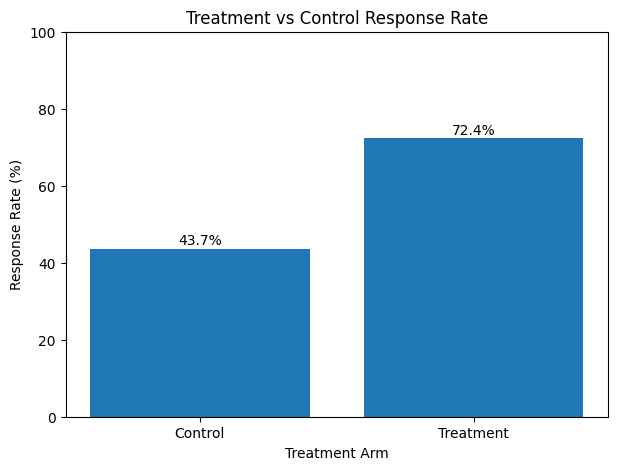

In [17]:
# visualisation
response_rates = participants.groupby("Treatment_Arm")["Response_Status"].apply(
    lambda x: (x == "Responder").mean() * 100
)

plt.figure(figsize=(7, 5))

plt.bar(
    response_rates.index,
    response_rates.values
)

plt.title("Treatment vs Control Response Rate")
plt.xlabel("Treatment Arm")
plt.ylabel("Response Rate (%)")

for i, value in enumerate(response_rates.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, 100)
plt.show()

In [18]:
#Adverse event rate by treatment arm

# Participants with at least one adverse event
participants_with_event = (
    adverse_events["Participant_ID"]
    .nunique()
)

# Participants with adverse events by treatment arm
event_participants = (
    adverse_events
    .merge(
        participants[["Participant_ID", "Treatment_Arm"]],
        on="Participant_ID",
        how="left"
    )
    .groupby("Treatment_Arm")["Participant_ID"]
    .nunique()
)

# Total participants in each arm
total_participants = participants.groupby("Treatment_Arm")["Participant_ID"].nunique()

# Adverse event rate
adverse_event_rate = (
    event_participants / total_participants * 100
)

print("Adverse event rate by treatment arm:")
print(adverse_event_rate.round(2))

Adverse event rate by treatment arm:
Treatment_Arm
Control      27.20
Treatment    27.44
Name: Participant_ID, dtype: float64


In [20]:
#Testing whether the adverse-event difference is statistically significant
control_events = event_participants["Control"]
treatment_events = event_participants["Treatment"]

control_no_events = total_participants["Control"] - control_events
treatment_no_events = total_participants["Treatment"] - treatment_events

table = [
    [control_events, control_no_events],
    [treatment_events, treatment_no_events]
]

chi2, p_value_ae, dof, expected = stats.chi2_contingency(table)

print("Chi-square statistic:", round(chi2, 2))
print("P-value:", p_value_ae)

Chi-square statistic: 0.06
P-value: 0.8050191456588781


In [21]:
#Analyze medication adherence
adherence_summary = (
    medication_adherence["Adherence_Band"]
    .value_counts()
    .sort_index()
)

print(adherence_summary)

Adherence_Band
High        2645
Low          462
Moderate    1893
Name: count, dtype: int64


In [22]:
#Does adherence relate to treatment response?
adherence_response = medication_adherence.merge(
    participants[["Participant_ID", "Response_Status"]],
    on="Participant_ID",
    how="left"
)

adherence_response_rate = (
    adherence_response
    .groupby("Adherence_Band")["Response_Status"]
    .apply(lambda x: (x == "Responder").mean() * 100)
    .sort_index()
)

print("Response rate by adherence:")
print(adherence_response_rate.round(2))

Response rate by adherence:
Adherence_Band
High        71.72
Low         77.92
Moderate    72.00
Name: Response_Status, dtype: float64


In [23]:
#Testing whether adherence bands are associated with response
adherence_table = pd.crosstab(
    adherence_response["Adherence_Band"],
    adherence_response["Response_Status"]
)

print(adherence_table)

chi2, p_value_adherence, dof, expected = stats.chi2_contingency(
    adherence_table
)

print("\nChi-square:", round(chi2, 2))
print("P-value:", p_value_adherence)

Response_Status  Non-Responder  Responder
Adherence_Band                           
High                       748       1897
Low                        102        360
Moderate                   530       1363

Chi-square: 7.81
P-value: 0.02012286322286189


In [24]:
#Subgroup analysis: baseline severity
severity_response = (
    participants
    .groupby(["Baseline_Severity", "Treatment_Arm"])["Response_Status"]
    .apply(lambda x: (x == "Responder").mean() * 100)
    .reset_index(name="Response_Rate")
)

print(severity_response)

  Baseline_Severity Treatment_Arm  Response_Rate
0              Mild       Control      36.448598
1              Mild     Treatment      66.034031
2          Moderate       Control      44.822071
3          Moderate     Treatment      74.554102
4            Severe       Control      51.548452
5            Severe     Treatment      76.923077


In [25]:
#Calculate the subgroup treatment effects automatically
severity_pivot = severity_response.pivot(
    index="Baseline_Severity",
    columns="Treatment_Arm",
    values="Response_Rate"
)

severity_pivot["Treatment_Effect"] = (
    severity_pivot["Treatment"]
    - severity_pivot["Control"]
)

print(severity_pivot.round(2))

Treatment_Arm      Control  Treatment  Treatment_Effect
Baseline_Severity                                      
Mild                 36.45      66.03             29.59
Moderate             44.82      74.55             29.73
Severe               51.55      76.92             25.37


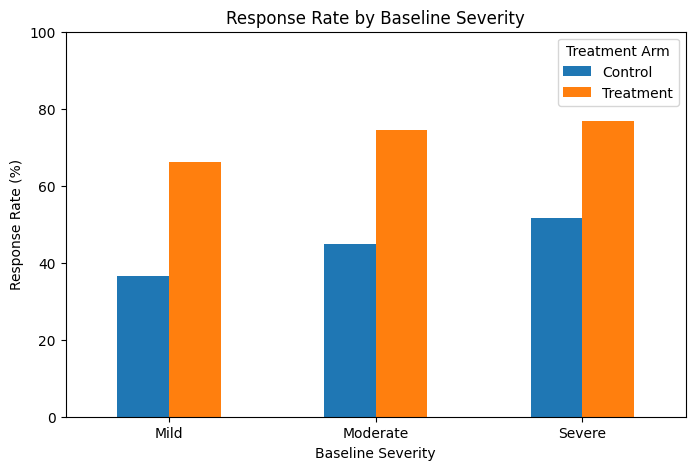

In [26]:
#subgroup visualization
severity_pivot[["Control", "Treatment"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Response Rate by Baseline Severity")
plt.xlabel("Baseline Severity")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Treatment Arm")
plt.ylim(0, 100)
plt.show()

In [27]:
#Risk-category subgroup analysis
risk_response = (
    participants
    .groupby(["Risk_Category", "Treatment_Arm"])["Response_Status"]
    .apply(lambda x: (x == "Responder").mean() * 100)
    .reset_index(name="Response_Rate")
)

print(risk_response)

  Risk_Category Treatment_Arm  Response_Rate
0          High       Control      42.918455
1          High     Treatment      71.258278
2           Low       Control      43.009192
3           Low     Treatment      71.272366
4        Medium       Control      44.439421
5        Medium     Treatment      73.741497
6       Unknown       Control      50.000000
7       Unknown     Treatment      78.571429


In [28]:
#final Python summary table
final_summary = pd.DataFrame({
    "Metric": [
        "Control Response Rate",
        "Treatment Response Rate",
        "Treatment Effect",
        "95% CI Lower",
        "95% CI Upper",
        "A/B Test P-Value",
        "Relative Improvement",
        "Number Needed to Treat",
        "Control Average Outcome Change",
        "Treatment Average Outcome Change",
        "Adverse Event Rate - Control",
        "Adverse Event Rate - Treatment",
        "Adverse Event P-Value"
    ],
    "Value": [
        control_rate * 100,
        treatment_rate * 100,
        difference * 100,
        lower * 100,
        upper * 100,
        p_value,
        relative_improvement,
        number_needed_to_treat,
        control_change.mean(),
        treatment_change.mean(),
        adverse_event_rate["Control"],
        adverse_event_rate["Treatment"],
        p_value_ae
    ]
})

print(final_summary.round(2))

                              Metric  Value
0              Control Response Rate  43.66
1            Treatment Response Rate  72.40
2                   Treatment Effect  28.74
3                       95% CI Lower  26.89
4                       95% CI Upper  30.59
5                   A/B Test P-Value   0.00
6               Relative Improvement  65.83
7             Number Needed to Treat   3.48
8     Control Average Outcome Change   8.58
9   Treatment Average Outcome Change  14.71
10      Adverse Event Rate - Control  27.20
11    Adverse Event Rate - Treatment  27.44
12             Adverse Event P-Value   0.81


In [29]:
## Save final statistical summary
final_summary.to_csv(
    "clinical_trial_statistical_summary.csv",
    index=False
)

# Save severity subgroup results
severity_pivot.round(2).to_csv(
    "clinical_trial_severity_subgroups.csv"
)

print("Files saved successfully.")

Files saved successfully.
